In [77]:
!pip install -q "numpy>=2.0.0" "node2vec" --no-deps

import os
import random
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from node2vec import Node2Vec
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print(f"Environment initialized. Seed set to {SEED}.")

Environment initialized. Seed set to 42.


In [78]:
data_path = "/kaggle/input/datasets/akay6483/com-dblp-ungraph/com-dblp.ungraph.txt"
if not os.path.exists(data_path):
    dataset_dir = "/kaggle/input/com-dblp.ungraph"
    data_path = os.path.join(dataset_dir, os.listdir(dataset_dir)[0])

G_full = nx.read_edgelist(data_path, comments='#', nodetype=int, create_using=nx.Graph())

# Snowball BFS Sampling: Naturally expands from a central node without artificial density constraints
seed_node = max(dict(G_full.degree()), key=dict(G_full.degree()).get)
target_nodes = 3000
sampled_nodes, queue = {seed_node}, [seed_node]

while queue and len(sampled_nodes) < target_nodes:
    curr = queue.pop(0)
    for neighbor in G_full.neighbors(curr):
        if neighbor not in sampled_nodes:
            sampled_nodes.add(neighbor)
            queue.append(neighbor)
            if len(sampled_nodes) >= target_nodes:
                break

candidate_subgraph = G_full.subgraph(sampled_nodes).copy()
lcc_nodes = max(nx.connected_components(candidate_subgraph), key=len)
G = candidate_subgraph.subgraph(lcc_nodes).copy()

print(f"Sampled Graph (Largest Connected Component) | Nodes: {G.number_of_nodes():,} | Edges: {G.number_of_edges():,}")

Sampled Graph (Largest Connected Component) | Nodes: 3,000 | Edges: 22,157


In [79]:
edges = list(G.edges())
num_test = int(0.2 * len(edges))
random.shuffle(edges)

test_pos_edges = set(edges[:num_test])
train_pos_edges = set(edges[num_test:])

# Remove positive test edges from the training graph
G_train = G.copy()
G_train.remove_edges_from(test_pos_edges)

# Uniform negative sampling (nodes that do not share an edge)
nodes = list(G.nodes())
neg_edges = set()
while len(neg_edges) < len(edges):
    u, v = random.sample(nodes, 2)
    if u != v and not G.has_edge(u, v):
        neg_edges.add((u, v))

neg_edges = list(neg_edges)
test_neg_edges = neg_edges[:num_test]
train_neg_edges = neg_edges[num_test:]

train_edges = list(train_pos_edges) + list(train_neg_edges)
y_train = np.array([1] * len(train_pos_edges) + [0] * len(train_neg_edges))

test_edges = list(test_pos_edges) + list(test_neg_edges)
y_test = np.array([1] * len(test_pos_edges) + [0] * len(test_neg_edges))

print(f"Train set: {len(train_pos_edges)} pos / {len(train_neg_edges)} neg")
print(f"Test set:  {len(test_pos_edges)} pos / {len(test_neg_edges)} neg")

Train set: 17726 pos / 17726 neg
Test set:  4431 pos / 4431 neg


In [80]:
def evaluate_heuristic(score_dict, name):
    scores = [score_dict.get((u, v), score_dict.get((v, u), 0.0)) for u, v in test_edges]
    auc = roc_auc_score(y_test, scores)
    ap = average_precision_score(y_test, scores)
    return name, auc, ap

jacc = dict(zip([e[:2] for e in nx.jaccard_coefficient(G_train, test_edges)],
                [e[2] for e in nx.jaccard_coefficient(G_train, test_edges)]))
aa = dict(zip([e[:2] for e in nx.adamic_adar_index(G_train, test_edges)],
              [e[2] for e in nx.adamic_adar_index(G_train, test_edges)]))
ra = dict(zip([e[:2] for e in nx.resource_allocation_index(G_train, test_edges)],
              [e[2] for e in nx.resource_allocation_index(G_train, test_edges)]))
pa = dict(zip([e[:2] for e in nx.preferential_attachment(G_train, test_edges)],
              [e[2] for e in nx.preferential_attachment(G_train, test_edges)]))

baseline_results = [
    evaluate_heuristic(jacc, "Jaccard Coeff"),
    evaluate_heuristic(aa, "Adamic-Adar Index"),
    evaluate_heuristic(ra, "Resource Allocation"),
    evaluate_heuristic(pa, "Preferential Attachment")
]

df_baselines = pd.DataFrame(baseline_results, columns=["Method", "ROC-AUC", "Avg Precision"])
print("--- Unsupervised Baselines ---")
print(df_baselines.to_string(index=False))

--- Unsupervised Baselines ---
                 Method  ROC-AUC  Avg Precision
          Jaccard Coeff 0.963915       0.964007
      Adamic-Adar Index 0.968405       0.969542
    Resource Allocation 0.968853       0.970097
Preferential Attachment 0.823173       0.848250


In [81]:
# Balanced Node2Vec parameters for an organic ~3k node graph
n2v = Node2Vec(G_train, dimensions=32, walk_length=20, num_walks=30, workers=2, quiet=True)
n2v_model = n2v.fit(window=10, min_count=1)

def build_feature_matrix(graph, edge_list):
    jacc = dict(zip([e[:2] for e in nx.jaccard_coefficient(graph, edge_list)],
                    [e[2] for e in nx.jaccard_coefficient(graph, edge_list)]))
    aa = dict(zip([e[:2] for e in nx.adamic_adar_index(graph, edge_list)],
                  [e[2] for e in nx.adamic_adar_index(graph, edge_list)]))
    ra = dict(zip([e[:2] for e in nx.resource_allocation_index(graph, edge_list)],
                  [e[2] for e in nx.resource_allocation_index(graph, edge_list)]))
    pa = dict(zip([e[:2] for e in nx.preferential_attachment(graph, edge_list)],
                  [e[2] for e in nx.preferential_attachment(graph, edge_list)]))

    features = []
    for u, v in edge_list:
        f_jacc = jacc.get((u, v), jacc.get((v, u), 0.0))
        f_aa = aa.get((u, v), aa.get((v, u), 0.0))
        f_ra = ra.get((u, v), ra.get((v, u), 0.0))
        f_pa = pa.get((u, v), pa.get((v, u), 0.0))
        
        cn = len(list(nx.common_neighbors(graph, u, v))) if graph.has_node(u) and graph.has_node(v) else 0

        if str(u) in n2v_model.wv and str(v) in n2v_model.wv:
            vec_u, vec_v = n2v_model.wv[str(u)], n2v_model.wv[str(v)]
            cos_sim = np.dot(vec_u, vec_v) / (np.linalg.norm(vec_u) * np.linalg.norm(vec_v))
            l2_dist = np.linalg.norm(vec_u - vec_v)
            hadamard_mean = np.mean(vec_u * vec_v)
        else:
            cos_sim, l2_dist, hadamard_mean = 0.0, 0.0, 0.0

        features.append([f_jacc, f_aa, f_ra, f_pa, cn, cos_sim, l2_dist, hadamard_mean])

    return np.array(features)

feature_names = [
    'Jaccard_Coeff', 'Adamic_Adar', 'Resource_Alloc', 'Pref_Attachment', 
    'Common_Neighbors', 'N2V_CosSim', 'N2V_L2Dist', 'N2V_HadamardMean'
]

X_train = build_feature_matrix(G_train, train_edges)
X_test = build_feature_matrix(G_train, test_edges)

print(f"Feature matrix shapes: Train={X_train.shape}, Test={X_test.shape}")

Feature matrix shapes: Train=(35452, 8), Test=(8862, 8)


In [82]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=6, random_state=SEED),
    "XGBoost": XGBClassifier(
        n_estimators=100, 
        max_depth=5, 
        learning_rate=0.1, 
        colsample_bytree=0.7,  # Forces model to use local heuristics
        subsample=0.8,         # Prevents overfitting to the distance metric
        random_state=SEED, 
        eval_metric='logloss'
    )
}

results = []

for name, clf in models.items():
    clf.fit(X_train, y_train)
    probs = clf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, probs)
    ap = average_precision_score(y_test, probs)
    results.append({"Model": name, "ROC-AUC": round(auc, 4), "Avg Precision": round(ap, 4)})

df_ml = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
print("--- Model Benchmarks ---")
print(df_ml.to_string(index=False))

--- Model Benchmarks ---
              Model  ROC-AUC  Avg Precision
            XGBoost   0.9806         0.9857
      Random Forest   0.9797         0.9857
Logistic Regression   0.9793         0.9852


In [83]:
best_clf = models["XGBoost"]
y_pred = best_clf.predict(X_test)

print("--- XGBoost Classification Report ---")
print(classification_report(y_test, y_pred, digits=4))

df_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("--- Feature Importances ---")
print(df_imp.to_string(index=False))

--- XGBoost Classification Report ---
              precision    recall  f1-score   support

           0     0.8763    0.9930    0.9310      4431
           1     0.9919    0.8599    0.9212      4431

    accuracy                         0.9264      8862
   macro avg     0.9341    0.9264    0.9261      8862
weighted avg     0.9341    0.9264    0.9261      8862

--- Feature Importances ---
         Feature  Importance
      N2V_L2Dist    0.581520
  Resource_Alloc    0.192380
      N2V_CosSim    0.158305
N2V_HadamardMean    0.022465
 Pref_Attachment    0.016424
     Adamic_Adar    0.014344
   Jaccard_Coeff    0.007963
Common_Neighbors    0.006600


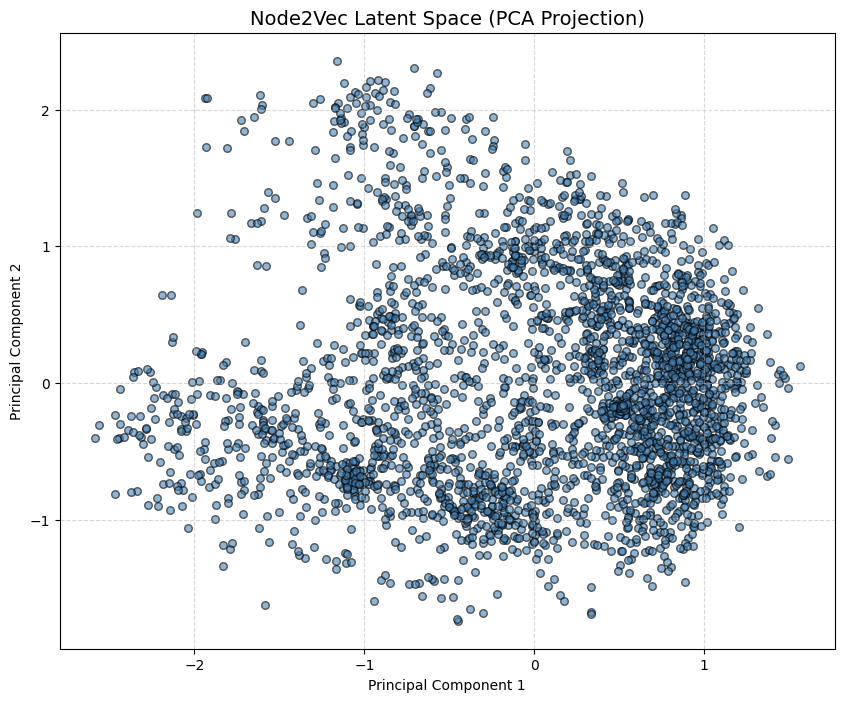

In [84]:
node_ids = list(n2v_model.wv.index_to_key)
vectors = np.array([n2v_model.wv[node] for node in node_ids])

pca = PCA(n_components=2, random_state=SEED)
pca_embeddings = pca.fit_transform(vectors)

plt.figure(figsize=(10, 8))
plt.scatter(pca_embeddings[:, 0], pca_embeddings[:, 1], alpha=0.6, c='steelblue', edgecolors='k', s=30)
plt.title("Node2Vec Latent Space (PCA Projection)", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()